In [2]:
!pip install notebook==6

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 6.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: notebook
    Found existing installation: notebook 7.2.1
    Uninstalling notebook-7.2.1:
      Successfully uninstalled notebook-7.2.1

[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [4]:
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [5]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [29]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 6.0 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.1.2 -> 25.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [7]:
data=pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")

In [8]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
data['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


<Axes: >

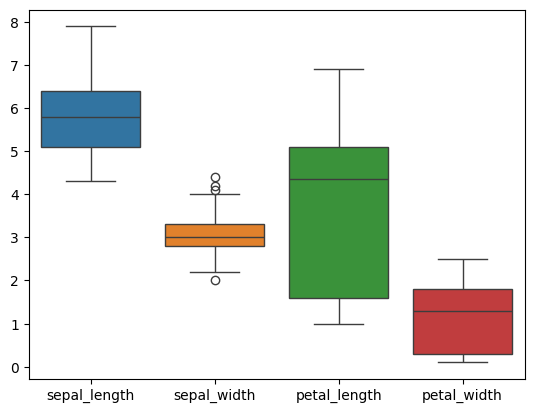

In [11]:
sns.boxplot(data)

In [12]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [13]:
X=data.drop("species", axis=1)
y=data['species']

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
train_temp=mms.fit_transform(X_train)
test_temp=mms.transform(X_test)
mms_X_train=pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
mms_X_test=pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [18]:
mms_X_train

,sepal_length,sepal_width,petal_length,petal_width
22,0.088235,0.666667,0.000000,0.041667
15,0.411765,1.000000,0.087719,0.125000
65,0.705882,0.458333,0.596491,0.541667
11,0.147059,0.583333,0.105263,0.041667
42,0.029412,0.500000,0.052632,0.041667
...,...,...,...,...
71,0.529412,0.333333,0.526316,0.500000
106,0.176471,0.208333,0.614035,0.666667
14,0.441176,0.833333,0.035088,0.041667
92,0.441176,0.250000,0.526316,0.458333


In [19]:
mms_X_test

,sepal_length,sepal_width,petal_length,petal_width
73,0.529412,0.333333,0.649123,0.458333
18,0.411765,0.750000,0.122807,0.083333
118,1.000000,0.250000,1.035088,0.916667
78,0.500000,0.375000,0.614035,0.583333
76,0.735294,0.333333,0.666667,0.541667
31,0.323529,0.583333,0.087719,0.125000
64,0.382353,0.375000,0.456140,0.500000
141,0.764706,0.458333,0.719298,0.916667
68,0.558824,0.083333,0.614035,0.583333
82,0.441176,0.291667,0.508772,0.458333


# 텐서플로우로 다중분류 분석하기

Sequential API

In [20]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2025-05-16 06:19:52.985262: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 06:19:53.371235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-16 06:19:53.516779: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-16 06:19:53.561996: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-16 06:19:53.840098: I tensorflow/core/platform/cpu_feature_guar

In [21]:
model=Sequential()
model.add(Input(shape=(mms_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(3, activation='softmax'))

I0000 00:00:1747376400.091578      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376400.202596      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376400.202678      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376400.207648      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747376400.207784      25 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

* 다중분류의 경우 사용하는 loss
    * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one hot encoding 된 경우
    * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

In [22]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history=model.fit(mms_X_train, y_train, epochs=100, batch_size=16,
                 validation_data=(mms_X_test, y_test))
pred=model.predict(mms_X_test)
result=pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))

Epoch 1/100


I0000 00:00:1747376402.171679     141 service.cc:146] XLA service 0x7f16d800aba0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747376402.171741     141 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-16 06:20:02.240163: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-16 06:20:02.526681: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


1/8 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.0000e+00 - loss: 1.1062

I0000 00:00:1747376404.823936     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 383ms/step - accuracy: 0.2826 - loss: 1.0962 - val_accuracy: 0.7000 - val_loss: 1.0393
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6759 - loss: 1.0299 - val_accuracy: 0.7000 - val_loss: 0.9954
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6934 - loss: 0.9811 - val_accuracy: 0.7000 - val_loss: 0.9389
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6289 - loss: 0.9368 - val_accuracy: 0.7000 - val_loss: 0.8760
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6824 - loss: 0.8537 - val_accuracy: 0.7000 - val_loss: 0.7986
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6628 - loss: 0.7925 - val_accuracy: 0.7000 - val_loss: 0.7141
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7302 - loss: 0.6889 - val_accuracy: 0.7000 - val_loss: 0.6288
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7189 - loss: 0.6284 - val_accuracy: 0.7333 - val_loss: 0.5574
Epoch 9/10

In [24]:
score=model.evaluate(mms_X_test, y_test)
print("test loss", score[0])
print('test accuracy', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9667 - loss: 0.0637
test loss 0.06368401646614075
test accuracy 0.9666666388511658


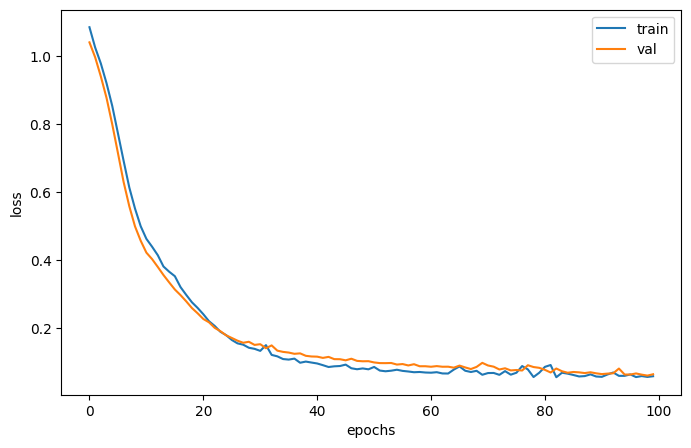

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

functional api

In [26]:
from keras.layers import Input, Dense
from keras.models import Model

In [27]:
inputs=Input(shape=(mms_X_train.shape[1],))

x=Dense(64, activation='relu')(inputs)
x=Dense(32, activation='relu')(x)
x=Dense(16, activation='relu')(x)

outputs=Dense(1, activation='softmax')(x)

model=Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(mms_X_train, y_train, epochs=100, batch_size=32, validation_data=(mms_X_test, y_test))
pred=model.predict(mms_X_test)
pred=pd.DataFrame(pred)
pred=pred[0].apply(lambda x:1 if x>0.5 else 0)
print(classification_report(y_test,pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.3823 - loss: 0.0000e+00

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/losses/losses.py:27: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 741ms/step - accuracy: 0.3742 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2992 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3346 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3065 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3658 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3533 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3106 - loss: 0.0000e+00 - val_accuracy: 0.3000 - val_loss: 0.0000e+00
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3585 - lo

/usr/local/lib/python3.11/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (30, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


NameError: name 'classification_report' is not defined

class 형으로 만들기

In [ ]:
class flower(Model):
    def __init__(self):
        super(flower, self).__init__()
        self.dense1=Dense(128, activation='relu')
        self.dense2=Dense(64, activation='relu')
        self.dense3=Dense(32, activation='relu')
        self.dense4=Dense(16, activation='relu')
        self.classifier=Dense(1, activation='softmax')
        
    def call(self, inputs):
        x=self.dense1(inputs)
        x=self.dense2(x)
        x=self.dense3(x)
        x=self.dense4(x)
        return self.classifier(x)

In [ ]:
model=flower()
model.build(input_shape=(None, mms_X_train.shape[1]))
print(model.summary())

In [ ]:
class flower(Model):
    def __init__(self):
        super(flower, self).__init__()
        self.dense1 = Dense(128, activation='relu')
        self.dense2 = Dense(64, activation='relu')
        self.dense3 = Dense(32, activation='relu')
        self.dense4 = Dense(16, activation='relu')
        self.classifier = Dense(1, activation='sigmoid')

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        x = self.dense3(x)
        x = self.dense4(x)
        return self.classifier(x)

# 모델 생성 시 입력 크기 지정
inputs = Input(shape=(mms_X_train.shape[1],))
model = flower()
output = model(inputs)
model = Model(inputs=inputs, outputs=output)

print(model.summary())

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=)

In [ ]:
inputs=Input(shape=(mms_X_train.shape[1],))
x=Dense(16, activation='relu')(inputs)
x=Dense(8, activation='relu')(x)
x=Dense(4, activation='relu')(x)
outputs=Dense(3, activation='softmax')(x)
model=Model(inputs=inputs, outputs=outputs)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(mms_X_train, epochs=100, batch_size=16, validation_data=(mms_X_test, y_test))

In [ ]:
class Iris(Model):
    def__init__(self):
        super(Iris, self).__init__()
        self.dense1=Dense(16, activation='relu')
        self.dense2=Dense(8, activation='relu')
        self.dense3=Dense(4, activation='relu')
        self.classifier=Dense(3, activation='softmax')
    
    def call(self, inputs):
        x=self.dense1(inputs)
        x=self.dense2(x)
        x=self.dense3(x)
        return self.classifier(x)

In [ ]:
model=lsis()
model.compile(loss='categor')